# nb4_results_three_axes
Results: the three axes — backs section 8, including the breast subtype panel.**Assertion-first.** Every documented value is checked against live data and reported `PASS` or `STALE`. A stale document fails loudly here instead of rotting silently.Code env: `primekg_kg`.

In [1]:
import dataiku, numpy as np, pandas as pd
import matplotlib; matplotlib.use("Agg")
import matplotlib.pyplot as plt
KS=[10,20,50,100,200]
FAIL=[]
def check(name,doc,live,tol=0.0,fmt="{:,}"):
    ok=(abs(doc-live)<=tol) if isinstance(doc,(int,float)) else (doc==live)
    if not ok: FAIL.append((name,doc,live))
    print(f"CHK|{'PASS ' if ok else 'STALE'}|{name:52s} doc={fmt.format(doc):>14s} live={fmt.format(live):>14s}")

## 8.1  the curated therapeutic label

In [2]:
kd=dataiku.Dataset("known_drug_truth").get_dataframe()
k8=kd[kd.score>=0.8]
print(f"LABEL|known_drug rows={len(kd):,}|at>=0.8={len(k8):,}|diseases={k8.disease_index.nunique()}")
# 107,593 is the RAW extract; known_drug_truth holds only what resolved onto the graph.
raw=dataiku.Dataset("raw_ot_known_drug").get_dataframe(columns=[
    dataiku.Dataset("raw_ot_known_drug").read_schema()[0]["name"]])
check("8.1 raw known_drug rows",107593,len(raw),tol=0)
check("8.1 resolving onto graph",67748,int(kd.disease_index.notna().sum()),tol=0)

LABEL|known_drug rows=67,748|at>=0.8=3,253|diseases=389
CHK|PASS |8.1 raw known_drug rows                              doc=       107,593 live=       107,593
CHK|PASS |8.1 resolving onto graph                             doc=        67,748 live=        67,748


## 8.3  discovery on the novel head

In [3]:
nde=dataiku.Dataset("novel_discovery_eval").get_dataframe()
for gt in ["approved","investigational","any"]:
    s=nde[nde.ground_truth==gt]
    if not len(s): continue
    l10=s.lift_top10.replace([np.inf],np.nan).mean(); l200=s.lift_top200.replace([np.inf],np.nan).mean()
    print(f"DISC|{gt:16s}|diseases={len(s):4d}|lift@10={l10:6.2f}|lift@200={l200:5.2f}|"
          f"hits@200={int(s.hits_top200.sum()):,}")
    if gt=="approved":
        check("8.3 approved lift@10",16.88,round(float(l10),2),tol=0.02,fmt="{:.2f}")
        check("8.3 approved lift@200",5.04,round(float(l200),2),tol=0.02,fmt="{:.2f}")
    if gt=="investigational":
        check("8.3 investigational lift@10",8.85,round(float(l10),2),tol=0.02,fmt="{:.2f}")

DISC|approved        |diseases= 122|lift@10= 16.88|lift@200= 5.04|hits@200=192
CHK|PASS |8.3 approved lift@10                                 doc=         16.88 live=         16.88
CHK|PASS |8.3 approved lift@200                                doc=          5.04 live=          5.04
DISC|investigational |diseases= 298|lift@10=  8.85|lift@200= 4.15|hits@200=1,801
CHK|PASS |8.3 investigational lift@10                          doc=          8.85 live=          8.85
DISC|any             |diseases= 312|lift@10=  8.51|lift@200= 4.04|hits@200=1,899


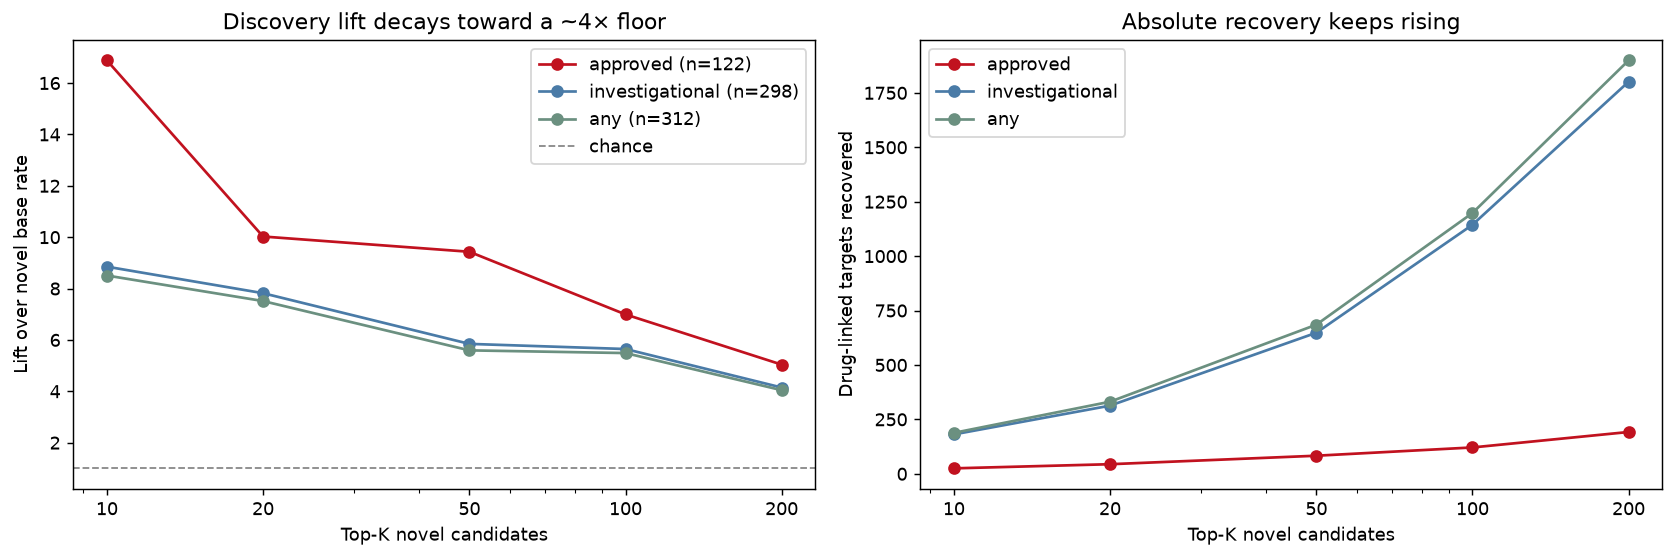

In [5]:
from io import BytesIO
from IPython.display import Image, display

fig, ax = plt.subplots(1, 2, figsize=(13, 4.4))

for gt, c in [
    ("approved", "#c1121f"),
    ("investigational", "#4a7ba7"),
    ("any", "#6b9080"),
]:
    s_ = nde[nde["ground_truth"] == gt]
    if s_.empty:
        continue

    lifts = [
        s_[f"lift_top{K}"].replace([np.inf, -np.inf], np.nan).mean()
        for K in KS
    ]
    hits = [int(s_[f"hits_top{K}"].sum()) for K in KS]

    ax[0].plot(KS, lifts, "o-", color=c, label=f"{gt} (n={len(s_)})")
    ax[1].plot(KS, hits, "o-", color=c, label=gt)

ax[0].axhline(1, color="#888", ls="--", lw=1, label="chance")
ax[0].set_xscale("log")
ax[0].set_xticks(KS)
ax[0].set_xticklabels(KS)
ax[0].set(
    xlabel="Top-K novel candidates",
    ylabel="Lift over novel base rate",
    title="Discovery lift decays toward a ~4× floor",
)
ax[0].legend()

ax[1].set_xscale("log")
ax[1].set_xticks(KS)
ax[1].set_xticklabels(KS)
ax[1].set(
    xlabel="Top-K novel candidates",
    ylabel="Drug-linked targets recovered",
    title="Absolute recovery keeps rising",
)
ax[1].legend()

fig.tight_layout()

plot_buffer = BytesIO()
fig.savefig(plot_buffer, format="png", dpi=130, bbox_inches="tight")
plot_buffer.seek(0)
display(Image(data=plot_buffer.getvalue()))

plt.close(fig)

==== 8.3  the ADOPTED label row, recomputed on the recipe's own methodology ====
This row of the section 8.3 table (curated known_drug >= 0.8) had NO source: compute_novel_discovery_eval
only emits approved/investigational/any, so the adopted row was measured ad hoc and then drifted.
Recomputed here with the recipe's exact gates (novel head = is_target==0, require >=200 novel rows
and >=1 linked pair, lift = (hits@K / K) / novel base rate), so it is asserted from now on.
NOTE: the pre-2026-08-21 row quoted expected@10 = 1.17, which implies ~83 evaluated diseases rather
than the 114 these gates select. That construction is not recoverable, so the row was recomputed
rather than reconciled.

In [6]:
M = 200000
_k8 = kd[kd.score >= 0.8].dropna(subset=["disease_index", "gene_index"])
_tkey = np.unique((_k8.disease_index.astype(np.int64)*M + _k8.gene_index.astype(np.int64)).values)
_sc = dataiku.Dataset("scored_champion").get_dataframe(
    columns=["disease_index", "gene_index", "is_target", "proba_1"])
_di = _sc.disease_index.astype(np.int64).values
_gi = _sc.gene_index.astype(np.int64).values
assert _gi.max() < M, "key base too small"
_key = _di*M + _gi
_pos = np.searchsorted(_tkey, _key); np.clip(_pos, 0, len(_tkey)-1, out=_pos)
_t = (_tkey[_pos] == _key).astype(np.int8)
_nv2 = pd.DataFrame({"d": _di, "p": _sc.proba_1.values, "t": _t})[_sc.is_target.values == 0]
del _sc, _di, _gi, _key, _pos, _t
_nv2 = _nv2.sort_values(["d", "p"], ascending=[True, False], kind="mergesort")
_nv2["rk"] = _nv2.groupby("d").cumcount() + 1
_g2 = _nv2.groupby("d")
_ag = pd.DataFrame({"n_nov": _g2.size(), "tot": _g2.t.sum()})
for K in [10, 200]:
    _ag["h%d" % K] = _nv2[_nv2.rk <= K].groupby("d").t.sum().reindex(_ag.index).fillna(0)
_ag = _ag[(_ag.n_nov >= 200) & (_ag.tot > 0)]
_ag["base"] = _ag.tot/_ag.n_nov
_cl = {}
for K in [10, 200]:
    _cl[K] = float(((_ag["h%d" % K]/K)/_ag.base).replace([np.inf], np.nan).mean())
print("CURATED|diseases=%d|lift@10=%.2f|lift@200=%.2f|expected@10=%.2f" % (
    len(_ag), _cl[10], _cl[200], (10*_ag.base).sum()))
check("8.3 curated>=0.8 diseases", 114, len(_ag))
check("8.3 curated>=0.8 lift@10", 21.32, round(_cl[10], 2), tol=0.02, fmt="{:.2f}")
check("8.3 curated>=0.8 lift@200", 5.23, round(_cl[200], 2), tol=0.02, fmt="{:.2f}")
del _nv2, _g2

CURATED|diseases=114|lift@10=21.32|lift@200=5.23|expected@10=1.61
CHK|PASS |8.3 curated>=0.8 diseases                            doc=           114 live=           114
CHK|PASS |8.3 curated>=0.8 lift@10                             doc=         21.32 live=         21.32
CHK|PASS |8.3 curated>=0.8 lift@200                            doc=          5.23 live=          5.23


## 8.4  tractability, naive vs degree-matched

In [7]:
tx=dataiku.Dataset("tractability_axis").get_dataframe()
nv=tx[tx.scope=="novel only"]
print("TRACTHDR|K|obs|dm_exp|pooled_dm|pooled_naive|macro_dm|macro_naive")
for K in [10,20,50,100,200]:
    obs=nv[f"demonstrated_obs{K}"].sum(); exp=nv[f"demonstrated_exp{K}"].sum()
    en=(nv[f"demonstrated_obs{K}"]/nv[f"demonstrated_naive{K}"].replace(0,np.nan)).sum()
    print(f"TRACT|{K}|{int(obs)}|{int(round(exp))}|{obs/exp:.2f}|{obs/en:.2f}|"
          f"{nv[f'demonstrated_dm{K}'].mean():.2f}|{nv[f'demonstrated_naive{K}'].mean():.2f}")
def _lifts(K):
    o=nv[f"demonstrated_obs{K}"].sum(); e=nv[f"demonstrated_exp{K}"].sum()
    en=(nv[f"demonstrated_obs{K}"]/nv[f"demonstrated_naive{K}"].replace(0,np.nan)).sum()
    return o/e, o/en, nv[f"demonstrated_dm{K}"].mean(), nv[f"demonstrated_naive{K}"].mean()
for K in [10,20,50,100,200]:
    pdm,pnv,mdm,mnv = _lifts(K)
    print("XOVER|K=%d|pooled dm%s naive|macro dm%s naive" % (
        K, ">" if pdm>pnv else "<", ">" if mdm>mnv else "<"))
# documented: dm WEAKENS at 10 under both; pooled turns at 20; macro not until 50
for K,want_p,want_m in [(10,False,False),(20,True,False),(50,True,True),(200,True,True)]:
    pdm,pnv,mdm,mnv=_lifts(K)
    check(f"8.4 dm>naive pooled @{K}", want_p, bool(pdm>pnv), tol=0, fmt="{}")
    check(f"8.4 dm>naive macro @{K}",  want_m, bool(mdm>mnv), tol=0, fmt="{}")
p10=nv.demonstrated_obs10.sum()/nv.demonstrated_exp10.sum()
p200=nv.demonstrated_obs200.sum()/nv.demonstrated_exp200.sum()
check("8.4 pooled dm lift @10",3.29,round(float(p10),2),tol=0.02,fmt="{:.2f}")
check("8.4 pooled dm lift @200",2.42,round(float(p200),2),tol=0.02,fmt="{:.2f}")
check("8.4 macro dm lift @10",3.11,round(float(nv.demonstrated_dm10.mean()),2),tol=0.02,fmt="{:.2f}")


TRACTHDR|K|obs|dm_exp|pooled_dm|pooled_naive|macro_dm|macro_naive
TRACT|10|2285|693|3.29|3.54|3.11|3.23
TRACT|20|4214|1383|3.05|3.00|2.90|2.97
TRACT|50|9683|3380|2.86|2.58|2.76|2.73
TRACT|100|17713|6645|2.67|2.35|2.62|2.49
TRACT|200|31475|13003|2.42|2.08|2.40|2.20
XOVER|K=10|pooled dm< naive|macro dm< naive
XOVER|K=20|pooled dm> naive|macro dm< naive
XOVER|K=50|pooled dm> naive|macro dm> naive
XOVER|K=100|pooled dm> naive|macro dm> naive
XOVER|K=200|pooled dm> naive|macro dm> naive
CHK|PASS |8.4 dm>naive pooled @10                              doc=         False live=         False
CHK|PASS |8.4 dm>naive macro @10                               doc=         False live=         False
CHK|PASS |8.4 dm>naive pooled @20                              doc=          True live=          True
CHK|PASS |8.4 dm>naive macro @20                               doc=         False live=         False
CHK|PASS |8.4 dm>naive pooled @50                              doc=          True live=          True
CHK

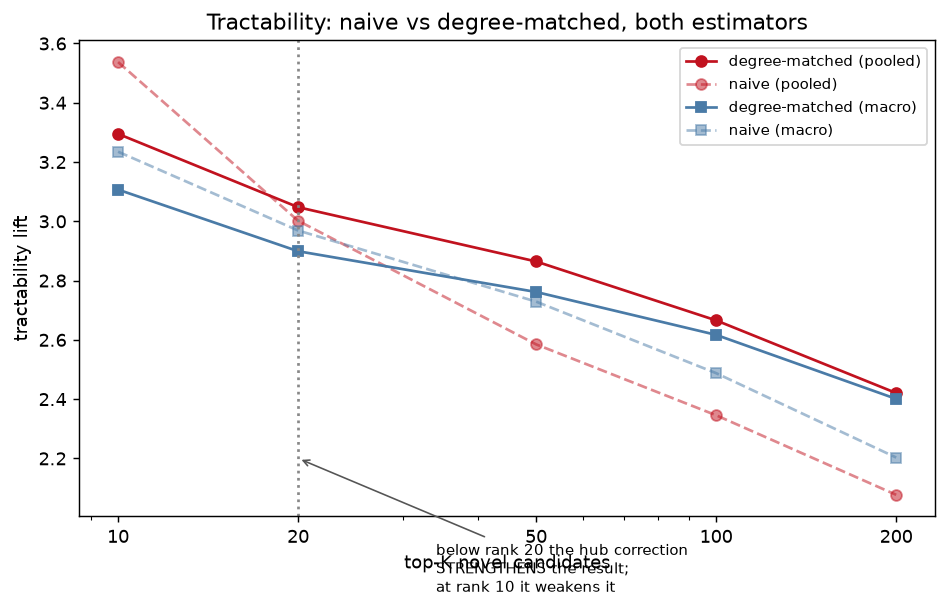

In [8]:
fig,ax=plt.subplots(figsize=(7.4,4.8))
pd_=[nv[f"demonstrated_obs{K}"].sum()/nv[f"demonstrated_exp{K}"].sum() for K in KS]
pn_=[nv[f"demonstrated_obs{K}"].sum()/
     (nv[f"demonstrated_obs{K}"]/nv[f"demonstrated_naive{K}"].replace(0,np.nan)).sum() for K in KS]
md_=[nv[f"demonstrated_dm{K}"].mean() for K in KS]
mn_=[nv[f"demonstrated_naive{K}"].mean() for K in KS]
ax.plot(KS,pd_,"o-",color="#c1121f",label="degree-matched (pooled)")
ax.plot(KS,pn_,"o--",color="#c1121f",alpha=.5,label="naive (pooled)")
ax.plot(KS,md_,"s-",color="#4a7ba7",label="degree-matched (macro)")
ax.plot(KS,mn_,"s--",color="#4a7ba7",alpha=.5,label="naive (macro)")
ax.axvline(20,color="#888",ls=":",lw=1.5)
ax.annotate("below rank 20 the hub correction\nSTRENGTHENS the result;\nat rank 10 it weakens it",
            xy=(20,2.2),xytext=(34,1.75),fontsize=8.5,
            arrowprops=dict(arrowstyle="->",color="#555",lw=.9))
ax.set_xscale("log"); ax.set_xticks(KS); ax.set_xticklabels(KS)
ax.set_xlabel("top-K novel candidates"); ax.set_ylabel("tractability lift")
ax.set_title("Tractability: naive vs degree-matched, both estimators")
ax.legend(fontsize=8.5); plt.tight_layout()

plot_buffer = BytesIO()
fig.savefig(plot_buffer, format="png", dpi=130, bbox_inches="tight")
plot_buffer.seek(0)

display(Image(data=plot_buffer.getvalue()))
plt.close(fig)

## 8.6  the three-axis filter

In [13]:
f3=dataiku.Dataset("filter_three_axes").get_dataframe()
print(f"FILTER|rows={len(f3)}|cols={list(f3.columns)[:8]}")

FILTER|rows=143|cols=['disease', 'stage', 'n', 'kd08_kept', 'kd08_lift', 'kd08_recall', 'appr_kept', 'appr_lift']


## 8.7  persona selection

In [14]:
f3=dataiku.Dataset("filter_three_axes").get_dataframe()
print(f"FILTER|rows={len(f3)}|cols={list(f3.columns)[:8]}")

# ==== 8.7  persona selection ====
pc=dataiku.Dataset("persona_candidates").get_dataframe()
n5=int((pc.n_criteria==5).sum())
print(f"PERSONA|diseases={len(pc)}|passing all five={n5}")
check("8.7 diseases passing 5 criteria",64,n5)
check("8.7 validation diseases",670,len(pc))

FILTER|rows=143|cols=['disease', 'stage', 'n', 'kd08_kept', 'kd08_lift', 'kd08_recall', 'appr_kept', 'appr_lift']
PERSONA|diseases=670|passing all five=64
CHK|PASS |8.7 diseases passing 5 criteria                      doc=            64 live=            64
CHK|PASS |8.7 validation diseases                              doc=           670 live=           670


## 8.10  the breast panel

In [15]:
bm=dataiku.Dataset("breast_panel_metrics").get_dataframe()
print("BREASTHDR|disease|pool|known|auc|hits50|exp50|verdict")
for _,r in bm.sort_values("n_known_targets",ascending=False).iterrows():
    print(f"BREAST|{str(r.disease)[:34]:34s}|{int(r.pool):6d}|{int(r.n_known_targets):4d}|"
          f"{r.auc:.4f}|{int(r.hits_at_50):3d}|{r.expected_at_50:6.2f}|{str(r.hits50_verdict)[:34]}")
h=bm[bm.disease.str.contains("HER2")]; t=bm[bm.disease.str.contains("triple")]
if len(h): check("8.10 HER2+ AUC",0.9365,round(float(h.auc.iloc[0]),4),tol=0.0006,fmt="{:.4f}")
if len(t): check("8.10 TNBC known targets",8,int(t.n_known_targets.iloc[0]))
bo=dataiku.Dataset("breast_panel_overlap").get_dataframe()
kp=bo[(bo.disease_a.str.contains("HER2")&bo.disease_b.str.contains("triple"))|
      (bo.disease_b.str.contains("HER2")&bo.disease_a.str.contains("triple"))]
if len(kp): check("8.10 HER2+ vs TNBC novel overlap",2,int(kp.novel_overlap.iloc[0]))
print(f"\nSUMMARY|{len(FAIL)} STALE")
for n,d,l in FAIL: print(f"FAILED|{n}|doc={d}|live={l}")

BREASTHDR|disease|pool|known|auc|hits50|exp50|verdict
BREAST|breast carcinoma                  | 13290| 864|0.8608| 49|  3.25|significant
BREAST|HER2 positive breast carcinoma    | 12272| 599|0.9365| 48|  2.44|significant
BREAST|female breast carcinoma           | 11946| 544|0.9359| 50|  2.28|significant
BREAST|breast lobular carcinoma          | 11723| 513|0.9337| 48|  2.19|significant
BREAST|breast cancer (parent term)       |  9067| 138|0.7072| 21|  0.76|significant
BREAST|invasive breast carcinoma         |  8170| 123|0.9351| 19|  0.75|significant
BREAST|luminal A breast carcinoma        |  8157| 101|0.8467| 14|  0.62|significant
BREAST|luminal B breast carcinoma        |  7439|  88|0.9106| 20|  0.59|significant
BREAST|breast adenocarcinoma             |  6738|  53|0.9043| 16|  0.39|significant
BREAST|estrogen-receptor positive breast |  5297|  33|0.8136|  4|  0.31|significant
BREAST|estrogen-receptor negative breast |  3474|  14|0.8411|  4|  0.20|significant
BREAST|triple-negative